<a href="https://colab.research.google.com/github/leticiasmx/Analise-de-dados/blob/main/Analise_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
PATH_COMPLETO = '/content/drive/MyDrive/aula0104/Cópia de Aula Visualização de Dados.ipynb'

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações padrão para gráficos (para começar limpo)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

Bibliotecas importadas e configurações aplicadas!


In [66]:
# Dados para o Desafio 1.1
dados_regiao = {
    'Regiao': ['Norte', 'Sul', 'Leste', 'Oeste'],
    'Vendas_Milhoes': [12.5, 18.2, 15.0, 9.8]
}
df_regiao = pd.DataFrame(dados_regiao)
print("\nDataFrame para Desafio 1.1:")
print(df_regiao)


DataFrame para Desafio 1.1:
  Regiao  Vendas_Milhoes
0  Norte            12.5
1    Sul            18.2
2  Leste            15.0
3  Oeste             9.8


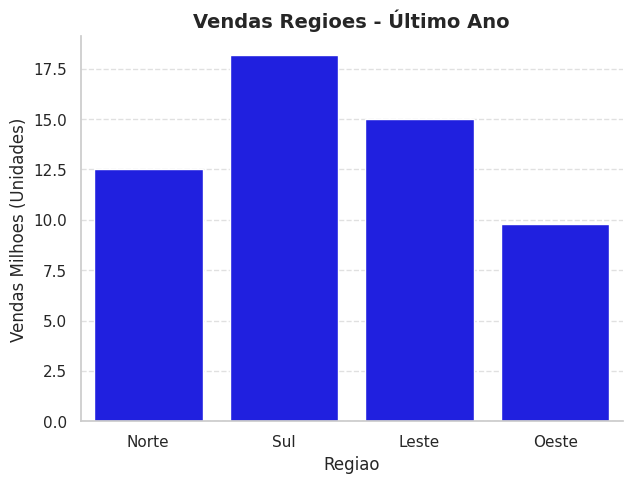

In [67]:
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: [Searbon]
# 2. Justificativa (Cleveland-McGill, Gestalt): [SUA RESPOSTA]

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns.barplot(...)
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(x='Regiao', y='Vendas_Milhoes', data=df_regiao, color='blue')
plt.title('Vendas Regioes - Último Ano', fontsize=14, fontweight='bold')
plt.xlabel('Regiao')
plt.ylabel('Vendas Milhoes (Unidades)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [68]:
# Dados para o Desafio 1.2
np.random.seed(42)
idades = np.random.normal(loc=35, scale=10, size=1000).astype(int)
idades = idades[(idades >= 18) & (idades <= 70)] # Limitar idades razoáveis
df_idades = pd.DataFrame({'Idade': idades})
print("\nDataFrame para Desafio 1.2 (primeiras 5 linhas):")
print(df_idades.head())


DataFrame para Desafio 1.2 (primeiras 5 linhas):
   Idade
0     39
1     33
2     41
3     50
4     32


In [69]:
# Dados para o Desafio 1.3
datas = pd.date_range(start='2024-03-01', periods=30)
np.random.seed(42)
acessos = np.random.randint(1000, 5000, 30)
# Simular uma queda nos últimos dias
acessos[-5:] = np.random.randint(500, 1500, 5)
df_acessos = pd.DataFrame({'Data': datas, 'Acessos': acessos})
print("\nDataFrame para Desafio 1.3 (primeiras 5 linhas):")
print(df_acessos.head())


DataFrame para Desafio 1.3 (primeiras 5 linhas):
        Data  Acessos
0 2024-03-01     4174
1 2024-03-02     4507
2 2024-03-03     1860
3 2024-03-04     2294
4 2024-03-05     2130


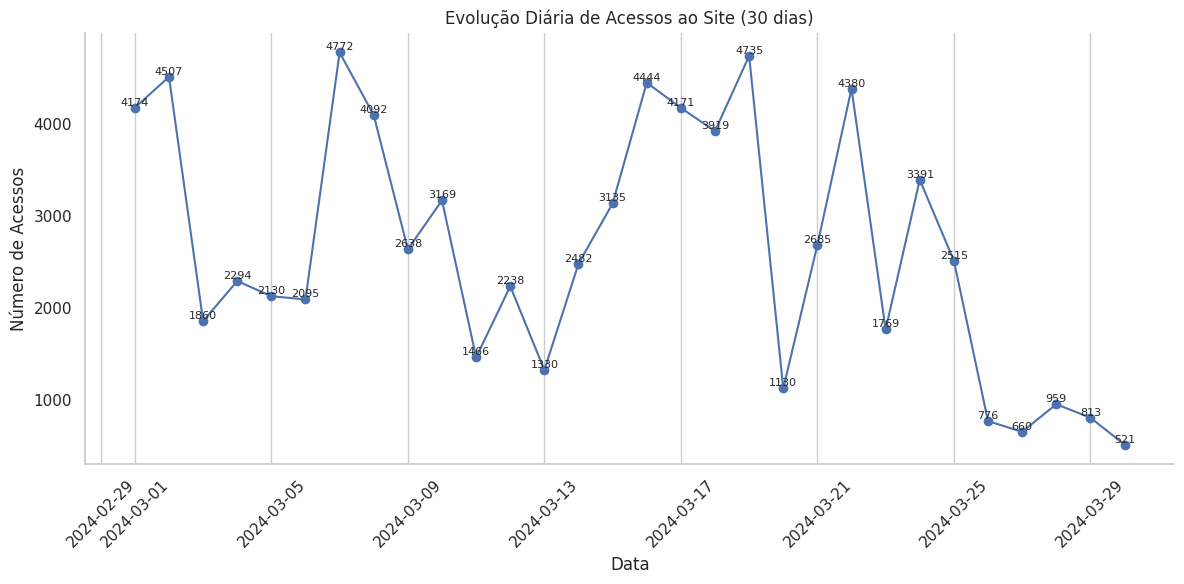

In [70]:
# Desafio 1.3
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: Gráfico de Linhas
# 2. Justificativa (Cleveland-McGill, Gestalt): Usei o gráfico de linhas porque ele é o mais adequado para mostrar a evolução dos acessos ao longo do tempo,
# já que os dados são diários.

# Seu código Python para o gráfico:
datas = pd.date_range(start='2024-03-01', periods=30)
np.random.seed(42)
acessos = np.random.randint(1000, 5000, 30)

# Simular uma queda nos últimos dias
acessos[-5:] = np.random.randint(500, 1500, 5)

df_acessos = pd.DataFrame({'Data': datas, 'Acessos': acessos})

# Gráfico de linhas
plt.figure(figsize=(12, 6))
plt.plot(df_acessos['Data'], df_acessos['Acessos'], marker='o')
plt.title('Evolução Diária de Acessos ao Site (30 dias)')
plt.xlabel('Data')
plt.ylabel('Número de Acessos')
plt.grid(axis='y')
plt.xticks(rotation=45)

# Mostrar valores nos pontos (opcional, pode tirar se ficar poluído)
for x, y in zip(df_acessos['Data'], df_acessos['Acessos']):
    plt.text(x, y, str(y), fontsize=8, ha='center', va='bottom')

plt.tight_layout()
plt.show()

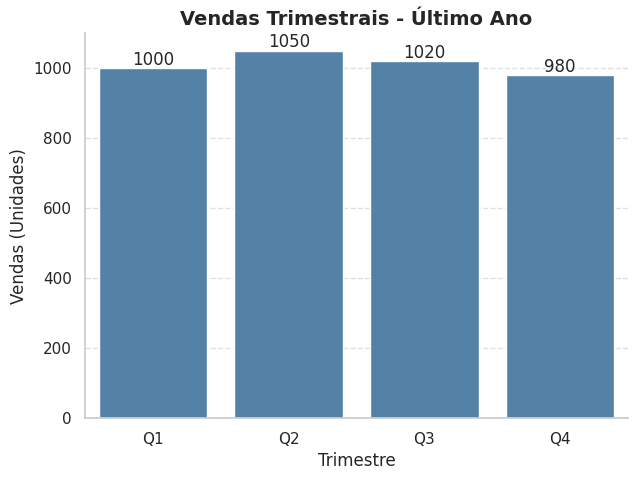

In [71]:
# 2.1 Problemas identificados:
#    a) O eixo Y começa em um valor alto (950), o que distorce a percepção dos dados
#    b) Isso faz a queda do Q4 parecer muito maior do que realmente é
#    c) Falta de clareza visual para interpretar corretamente os valores reais

# 2. Seu código Python refatorado:
dados_trimestrais = {
    'Trimestre': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Vendas': [1000, 1050, 1020, 980]
}
df_trimestral = pd.DataFrame(dados_trimestrais)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Trimestre', y='Vendas', data=df_trimestral, color='steelblue')

# Correção principal: eixo Y começando do zero
ax.set_ylim(0, 1100)

# Melhorias visuais
ax.set_title('Vendas Trimestrais - Último Ano', fontsize=14, fontweight='bold')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Vendas (Unidades)')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Valores nas barras
for i, v in enumerate(df_trimestral['Vendas']):
    ax.text(i, v + 10, str(v), ha='center')

plt.show()

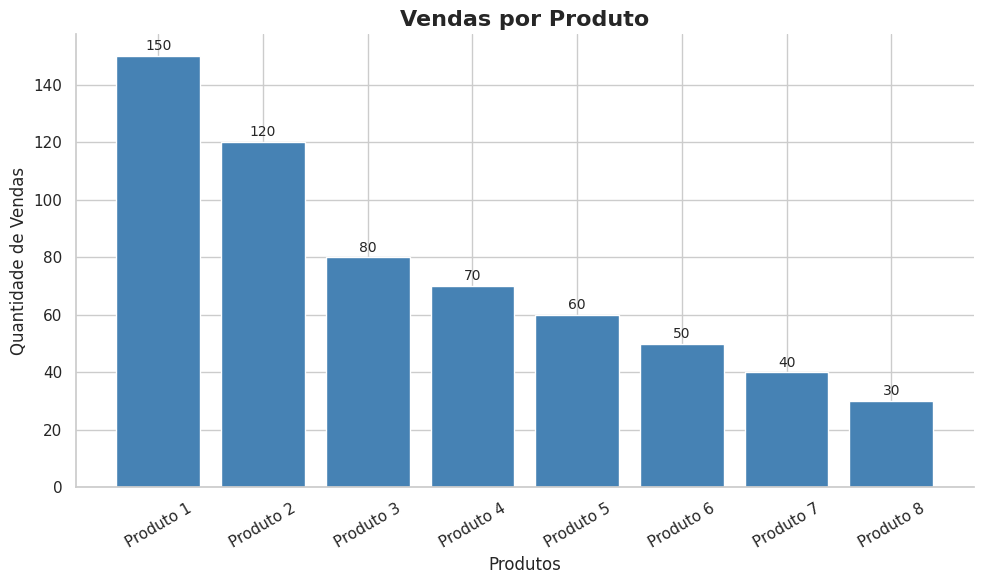

In [72]:
# DESAFIO 2.2
# Problemas identificados:
# a) O gráfico de pizza é indicado que tenha de 2 a 6 fatias e no gráfico estava com 8, isso deixava o gráfico confuso
# b) Exesso de informação no código
# c) Falta de orgnização

# Dados
dados_produtos = {
    'Produto': [f'Produto {i}' for i in range(1, 9)],
    'Vendas': [150, 120, 80, 70, 60, 50, 40, 30]
}

df_produtos = pd.DataFrame(dados_produtos)

# Ordenar por vendas (decrescente)
df_produtos = df_produtos.sort_values(by='Vendas', ascending=False)

# Cor única
cores = ['steelblue']

# Gráfico de barras (mais adequado que pizza)
plt.figure(figsize=(10, 6))
barras = plt.bar(df_produtos['Produto'], df_produtos['Vendas'], color=cores)

plt.title('Vendas por Produto', fontsize=16, fontweight='bold')
plt.xlabel('Produtos', fontsize=12)
plt.ylabel('Quantidade de Vendas', fontsize=12)

plt.xticks(rotation=30)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 2,
             f'{int(altura)}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

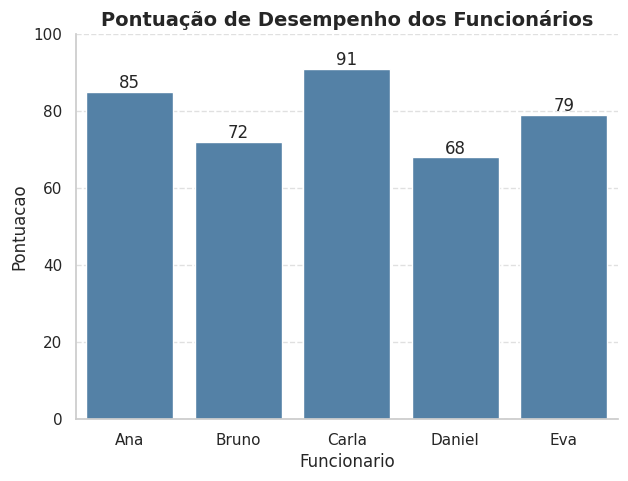

In [73]:
# DESAFIO 2.3
# 1. Problemas identificados:
# a) Uso de cores aleatórias sem significado, o que polui a visualização
# b) Falta de padronização visual, deixando o gráfico menos profissional

# 2. Código Python refatorado
dados_funcionarios = {
    'Funcionario': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eva'],
    'Pontuacao': [85, 72, 91, 68, 79]
}
df_funcionarios = pd.DataFrame(dados_funcionarios)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Funcionario', y='Pontuacao', data=df_funcionarios, color='steelblue')

ax.set_title('Pontuação de Desempenho dos Funcionários', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Valores nas barras
for i, v in enumerate(df_funcionarios['Pontuacao']):
    ax.text(i, v + 1, str(v), ha='center')

plt.show()

/tmp/ipykernel_4924/2500126232.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')


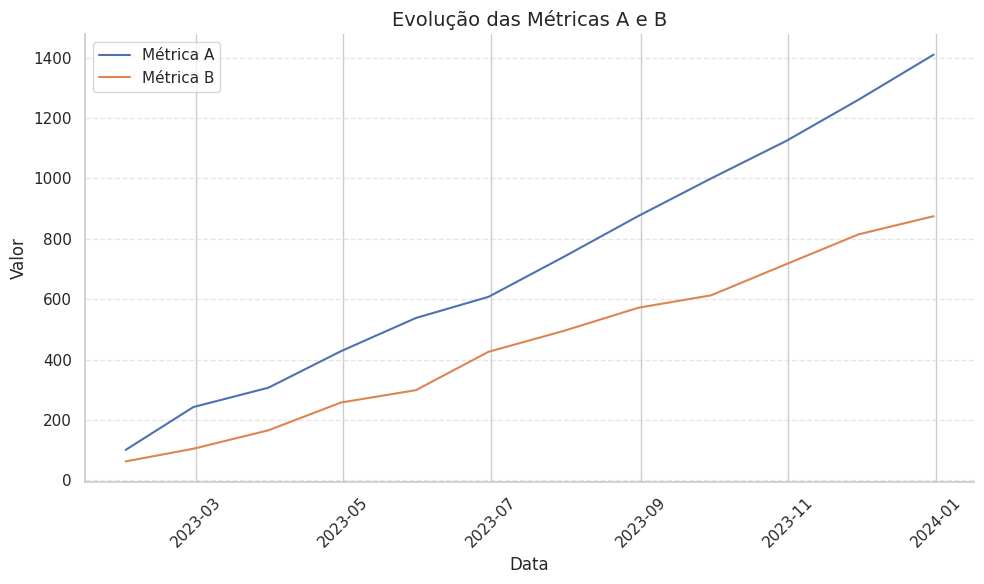

In [74]:
# DESAFIO 2.4
# 1. Problemas identificados:
# a) Excesso de elementos visuais (marcadores, estilos de linha diferentes e cores fortes)
# b) Grid muito chamativo, o que polui o gráfico
# c) Legenda fora do gráfico, dificultando a leitura

# 2. Código Python refatorado:
datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')
np.random.seed(42)
metrica_a = np.random.randint(50, 150, 12).cumsum()
metrica_b = np.random.randint(40, 130, 12).cumsum()

df_metricas = pd.DataFrame({
    'Data': datas_mes,
    'Metrica_A': metrica_a,
    'Metrica_B': metrica_b
})

plt.figure(figsize=(10, 6))

# Linhas mais simples
plt.plot(df_metricas['Data'], df_metricas['Metrica_A'], label='Métrica A')
plt.plot(df_metricas['Data'], df_metricas['Metrica_B'], label='Métrica B')

# Ajustes visuais
plt.title('Evolução das Métricas A e B', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Valor')

# Grid mais leve (apenas horizontal)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legenda dentro do gráfico
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

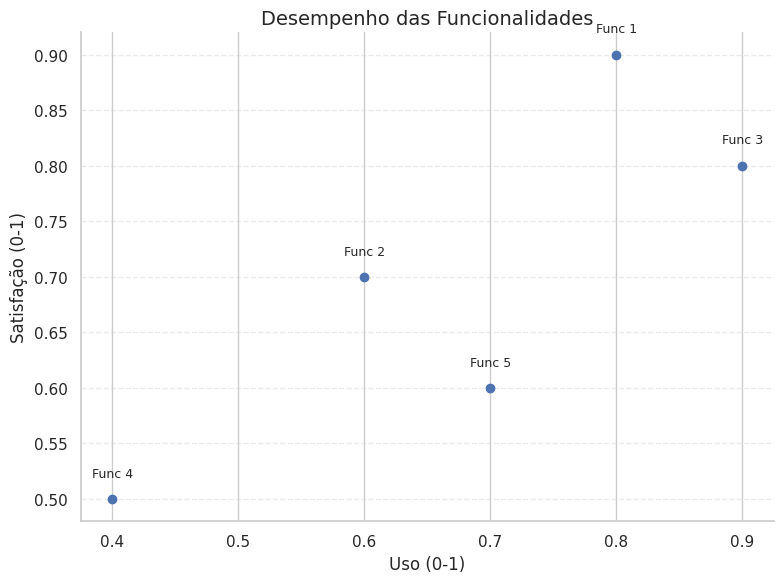

In [75]:
# DESAFIO 2.4
# 1. Problemas identificados:
#    a) Uso de gráfico de bolhas adiciona complexidade desnecessária
#    b) Difícil comparar tamanhos das bolhas (impacto)
#    c) Visual poluído com muitas variáveis ao mesmo tempo

# 2. Seu código Python refatorado (gráfico de dispersão):
import pandas as pd
import matplotlib.pyplot as plt

# Dados
dados_funcionalidades = {
    'Funcionalidade': [f'Func {i}' for i in range(1, 6)],
    'Uso': [0.8, 0.6, 0.9, 0.4, 0.7],
    'Satisfacao': [0.9, 0.7, 0.8, 0.5, 0.6],
    'Impacto': [100, 50, 120, 30, 80]
}
df_funcionalidades = pd.DataFrame(dados_funcionalidades)

plt.figure(figsize=(8, 6))

# Gráfico de dispersão simples
plt.scatter(df_funcionalidades['Uso'], df_funcionalidades['Satisfacao'])

# Rótulos das funcionalidades
for i, row in df_funcionalidades.iterrows():
    plt.text(row['Uso'], row['Satisfacao'] + 0.02, row['Funcionalidade'],
             fontsize=9, ha='center')

# Títulos
plt.title('Desempenho das Funcionalidades', fontsize=14)
plt.xlabel('Uso (0-1)')
plt.ylabel('Satisfação (0-1)')

# Grid leve
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [76]:
# Dados para o Desafio 1.3
datas = pd.date_range(start='2024-03-01', periods=30)
np.random.seed(42)
acessos = np.random.randint(1000, 5000, 30)
# Simular uma queda nos últimos dias
acessos[-5:] = np.random.randint(500, 1500, 5)
df_acessos = pd.DataFrame({'Data': datas, 'Acessos': acessos})
print("\nDataFrame para Desafio 1.3 (primeiras 5 linhas):")
print(df_acessos.head())


DataFrame para Desafio 1.3 (primeiras 5 linhas):
        Data  Acessos
0 2024-03-01     4174
1 2024-03-02     4507
2 2024-03-03     1860
3 2024-03-04     2294
4 2024-03-05     2130


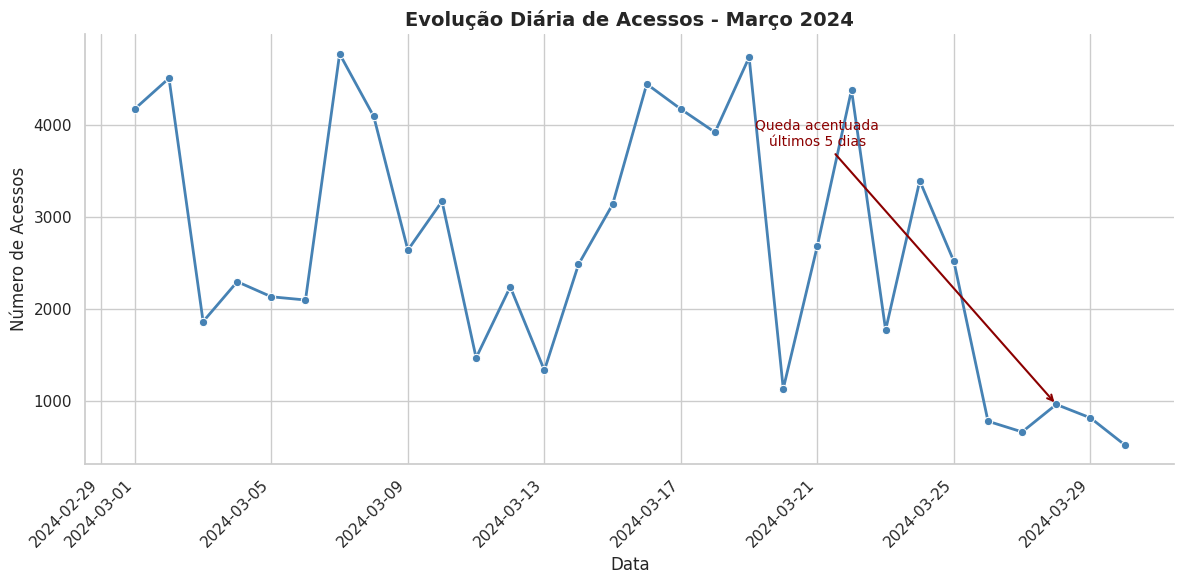

In [49]:
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: [Gráfico de linhas]
# 2. Justificativa (Cleveland-McGill, Gestalt): [Escolhi o gráfico de linhas, pois ele usa posição em eixo comum e ângulo,direção, que são atributos precisos para mostrar evolução temporal e quedas.]

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns.lineplot(...)
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

# Gráfico de linhas
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_acessos,
    x='Data',
    y='Acessos',
    marker='o',
    markersize=6,
    linewidth=2,
    color='steelblue'
)

plt.annotate('Queda acentuada\núltimos 5 dias',
             xy=(df_acessos['Data'].iloc[-3], df_acessos['Acessos'].iloc[-3]),
             xytext=(df_acessos['Data'].iloc[-10], df_acessos['Acessos'].max() - 1000),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
             fontsize=10, color='darkred', ha='center')

plt.title('Evolução Diária de Acessos - Março 2024', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Número de Acessos', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [77]:
# Dados para o Desafio 1.4
np.random.seed(42)
investimento_marketing = np.random.randint(10000, 50000, 12)
vendas_mensais = investimento_marketing * 5 + np.random.randint(-5000, 5000, 12)
df_marketing_vendas = pd.DataFrame({
    'Investimento_Marketing': investimento_marketing,
    'Vendas_Mensais': vendas_mensais
})
print("\nDataFrame para Desafio 1.4 (primeiras 5 linhas):")
print(df_marketing_vendas.head())


DataFrame para Desafio 1.4 (primeiras 5 linhas):
   Investimento_Marketing  Vendas_Mensais
0                   25795          129286
1                   10860           54351
2                   48158          242210
3                   21284          102604
4                   16265           80880


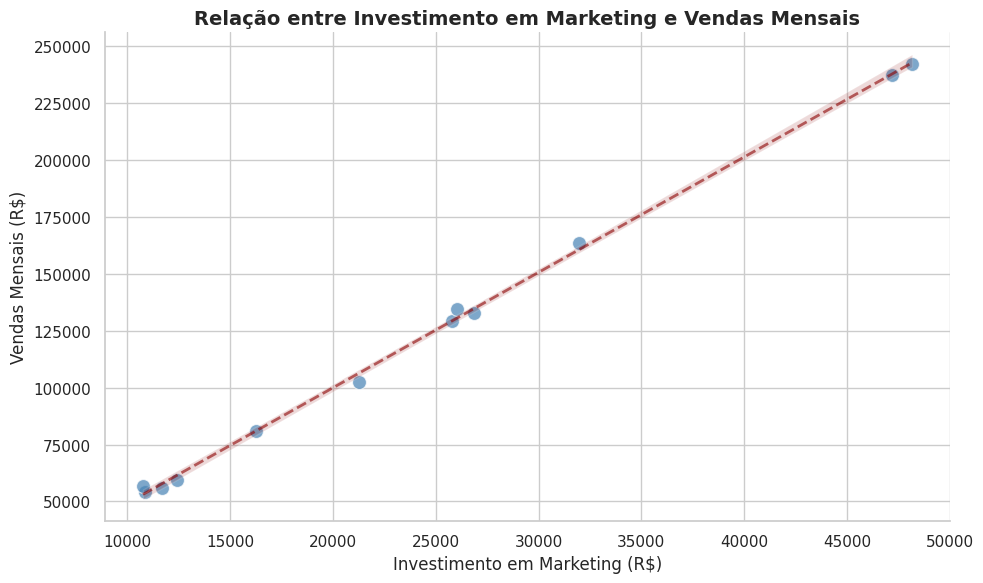

In [78]:
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: [Gráfico de dispersão]
# 2. Justificativa (Cleveland-McGill, Gestalt): [tem a posição ao longo de um eixo comum, que é o atributo perceptual mais preciso para comparação quantitativa]

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns.scatterplot(...)
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_marketing_vendas,
    x='Investimento_Marketing',
    y='Vendas_Mensais',
    color='steelblue',
    s=100,
    alpha=0.7
)

sns.regplot(
    data=df_marketing_vendas,
    x='Investimento_Marketing',
    y='Vendas_Mensais',
    scatter=False,
    color='darkred',
    line_kws={'linestyle': '--', 'linewidth': 2, 'alpha': 0.6}
)

plt.title('Relação entre Investimento em Marketing e Vendas Mensais', fontsize=14, fontweight='bold')
plt.xlabel('Investimento em Marketing (R$)', fontsize=12)
plt.ylabel('Vendas Mensais (R$)', fontsize=12)


plt.tight_layout()
plt.show()


In [79]:
# Dados para o Desafio 1.5
dados_categorias = {
    'Categoria': ['Eletrônicos', 'Vestuário', 'Alimentos', 'Livros', 'Serviços'],
    'Vendas_Milhoes': [35.0, 20.0, 15.0, 10.0, 5.0]
}
df_categorias = pd.DataFrame(dados_categorias)
print("\nDataFrame para Desafio 1.5:")
print(df_categorias)


DataFrame para Desafio 1.5:
     Categoria  Vendas_Milhoes
0  Eletrônicos            35.0
1    Vestuário            20.0
2    Alimentos            15.0
3       Livros            10.0
4     Serviços             5.0


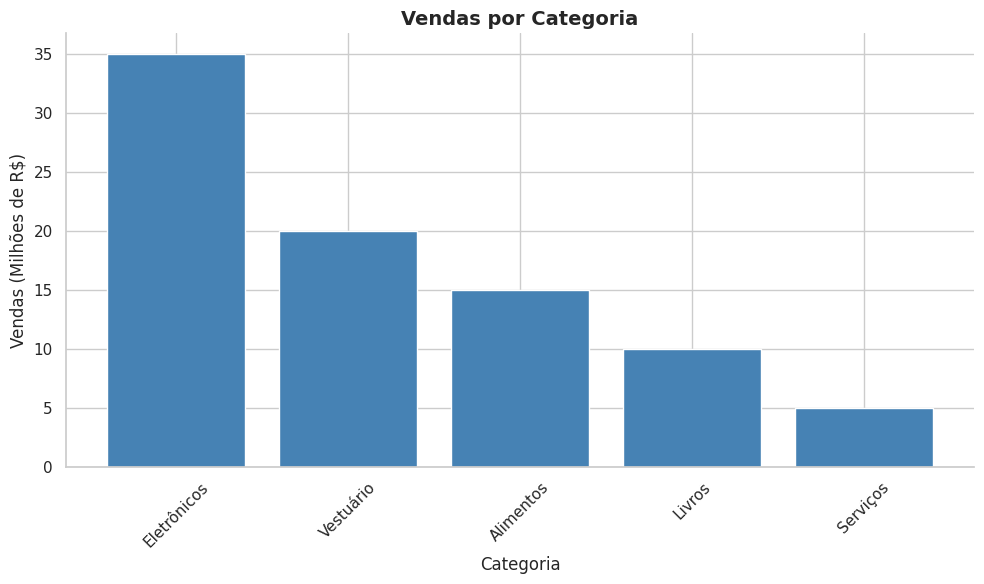

In [82]:
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: [Gráfico de barras]
# 2. Justificativa (Cleveland-McGill, Gestalt): [Gráfico de barras usa posição em altura, mais preciso para comparação quantitativa.]

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# plt.pie(...)
# plt.title(...)
# plt.show()

plt.figure(figsize=(10, 6))
plt.bar(df_categorias['Categoria'], df_categorias['Vendas_Milhoes'], color='steelblue')
plt.title('Vendas por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Vendas (Milhões de R$)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()